# EDA — Real Users (Twitter profiles)

**File:** `data/real_users.csv`

This notebook explores the raw Twitter-style account dataset before building a
fake-account detection model. Rows in this file are **genuine/real** accounts.

The plan:
1. Load and take a first look
2. Missing values
3. Duplicates
4. Numeric feature analysis
5. Categorical / text feature analysis
6. Correlations
7. Comparison with the opposite class (real vs fake)
8. Key observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../data/real_users.csv"
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
df.head()

Rows: 2,500  Columns: 34


,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,lang,time_zone,location,default_profile,default_profile_image,geo_enabled,profile_image_url,profile_banner_url,profile_use_background_image,profile_background_image_url_https,profile_text_color,profile_image_url_https,profile_sidebar_border_color,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,dataset
0,0.000000e+00,Mamma con i tacchi,NaN,2125.688723,0.000000,371.008902,1.962508,10.100250,NaN,http://t.co/WRvheMrL,it,NaN,NaN,0.000000,-0.0,-0.000000,http://a0.twimg.com/profile_images/2667435229/...,NaN,-0.000000,https://si0.twimg.com/images/themes/theme11/bg...,362720,NaN,NaN,1.092992,NaN,NaN,NaN,B40B43,0.000000,-0.0,-0.0,"Mamma felice di due bimbe (Viola e Vittoria), ...",NaN,NaN
1,0.000000e+00,Gianluca Pini,GLPini,0.000000,0.000000,624.280013,0.000000,0.000000,Mon Nov 07 11:00:27 +0000 2011,NaN,it,NaN,NaN,0.000000,0.0,1.666252,NaN,NaN,0.000000,NaN,333333,https://si0.twimg.com/profile_images/304106629...,C0DEED,-0.000000,DDEEF6,http://a0.twimg.com/profile_background_images/...,NaN,0084B4,0.000000,-0.0,0.0,You think I'm a hero? I am not a hero. And if ...,NaN,NaN
2,1.820663e+09,Marta Perego,MartaPerego88,31.131715,0.000000,235.073296,1060.129667,0.000000,NaN,NaN,NaN,NaN,www.peregoalbum.it,2.635171,0.0,0.000000,NaN,https://si0.twimg.com/profile_banners/93446688...,3.113465,https://si0.twimg.com/images/themes/theme1/bg.png,333333,https://si0.twimg.com/profile_images/342617251...,C0DEED,-0.000000,NaN,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,NaN,0.000000,0.0,-0.0,*,2015-02-14 10:54:49,E13
3,3.263751e+08,Bruno Lapira,NaN,0.000000,87.572035,0.000000,0.000000,0.236213,Sun Aug 07 13:02:27 +0000 2011,http://www.facebook.com/bruno.lapira,NaN,NaN,Siracusa,0.000000,0.0,-0.000000,NaN,https://si0.twimg.com/profile_banners/35024485...,1.983736,NaN,NaN,https://si0.twimg.com/profile_images/327668338...,000000,0.000000,C0DFEC,NaN,022330,NaN,8004.629652,0.0,0.0,Cittadino del mondo che tra Architecture&Desig...,2015-02-14 10:54:49,NaN
4,5.671719e+08,Alessandra Borroni,ale_pilli,7503.508668,0.000000,176.782123,1132.948817,-0.000000,Mon Apr 30 20:10:04 +0000 2012,NaN,NaN,Rome,NaN,2.295613,0.0,1.999759,http://a0.twimg.com/profile_images/3434644215/...,NaN,1.436948,https://si0.twimg.com/images/themes/theme1/bg.png,333333,NaN,C0DEED,-0.000000,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,9193.349172,0.0,0.0,NaN,2015-02-14 10:54:49,E13


## 1. First look — structure, dtypes, samples

In [2]:
df.info()
df.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  2500 non-null   float64
 1   name                                1620 non-null   str    
 2   screen_name                         1651 non-null   str    
 3   statuses_count                      2500 non-null   float64
 4   followers_count                     2500 non-null   float64
 5   friends_count                       2500 non-null   float64
 6   favourites_count                    2500 non-null   float64
 7   listed_count                        2500 non-null   float64
 8   created_at                          1625 non-null   str    
 9   url                                 514 non-null    str    
 10  lang                                1610 non-null   str    
 11  time_zone                           1117 non-null   st

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,lang,time_zone,location,default_profile,default_profile_image,geo_enabled,profile_image_url,profile_banner_url,profile_use_background_image,profile_background_image_url_https,profile_text_color,profile_image_url_https,profile_sidebar_border_color,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,dataset
1447,1.347038e+08,NaN,pensoedico,349.993754,0.000000,1353.766711,3.305507,0.000000,Wed Oct 13 16:26:06 +0000 2010,NaN,NaN,Athens,terra,0.752995,0.0,0.000000,NaN,NaN,2.736531,NaN,333333,https://si0.twimg.com/profile_images/322804192...,C0DEED,0.000000,NaN,NaN,C0DEED,NaN,21352.123688,0.0,0.0,NaN,2015-02-14 10:54:49,E13
1114,0.000000e+00,Grazia Scuderi,NaN,-0.000000,3.058334,153.520865,0.000000,0.000000,NaN,NaN,it,NaN,NaN,0.000000,0.0,-0.000000,NaN,NaN,0.436875,NaN,NaN,https://twimg0-a.akamaihd.net/profile_images/3...,C0DEED,2.890592,NaN,http://a0.twimg.com/profile_background_images/...,EBE5C1,NaN,0.000000,0.0,0.0,E poi ci sono quei momenti in cui il cuore bat...,2015-02-14 10:54:49,E13
1064,8.220923e+07,NaN,NaN,1027.570221,0.000000,0.000000,0.000000,0.000000,Fri Jan 14 11:24:16 +0000 2011,http://t.co/eHwUdu00,it,Rome,NaN,0.000000,-0.0,3.090346,http://a0.twimg.com/profile_images/2186758291/...,https://si0.twimg.com/profile_banners/23810734...,1.565441,https://si0.twimg.com/profile_background_image...,NaN,https://si0.twimg.com/profile_images/218675829...,NaN,0.000000,C0DFEC,http://a0.twimg.com/profile_background_images/...,NaN,0084B4,4429.598595,0.0,0.0,NaN,2015-02-14 10:54:49,E13
2287,1.269150e+08,NaN,wantlovatoshug,0.000000,0.000000,1152.651010,521.039111,2.672998,Mon Jan 02 18:32:35 +0000 2012,NaN,NaN,Athens,sofia spadoni.❤,0.000000,-0.0,0.000000,NaN,NaN,0.000000,NaN,362720,NaN,NaN,1.894576,NaN,http://a0.twimg.com/profile_background_images/...,D32C84,NaN,10938.560830,0.0,0.0,oned|justin|demi|miley|conor|selena IDOLIϟ♡la...,2015-02-14 10:54:49,E13
1537,1.443450e+09,Mariachiara Sparvoli,NaN,203.594522,0.000000,0.000000,0.000000,0.000000,Thu Sep 29 19:43:14 +0000 2011,NaN,en,NaN,Milan,0.000000,0.0,0.000000,NaN,https://si0.twimg.com/profile_banners/38227110...,0.000000,https://si0.twimg.com/profile_background_image...,NaN,https://si0.twimg.com/profile_images/304625008...,FFFFFF,0.000000,99CC33,NaN,1A1B1F,NaN,0.000000,0.0,0.0,NaN,2015-02-14 10:54:49,E13


## 2. Missing values

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
print(f"Columns with missing values: {len(missing_tbl)} / {df.shape[1]}")
missing_tbl


Columns with missing values: 20 / 34


,missing_count,missing_pct
url,1986,79.44
profile_banner_url,1424,56.96
time_zone,1383,55.32
location,1376,55.04
profile_sidebar_border_color,929,37.16
description,909,36.36
lang,890,35.60
profile_image_url,887,35.48
dataset,886,35.44
name,880,35.20


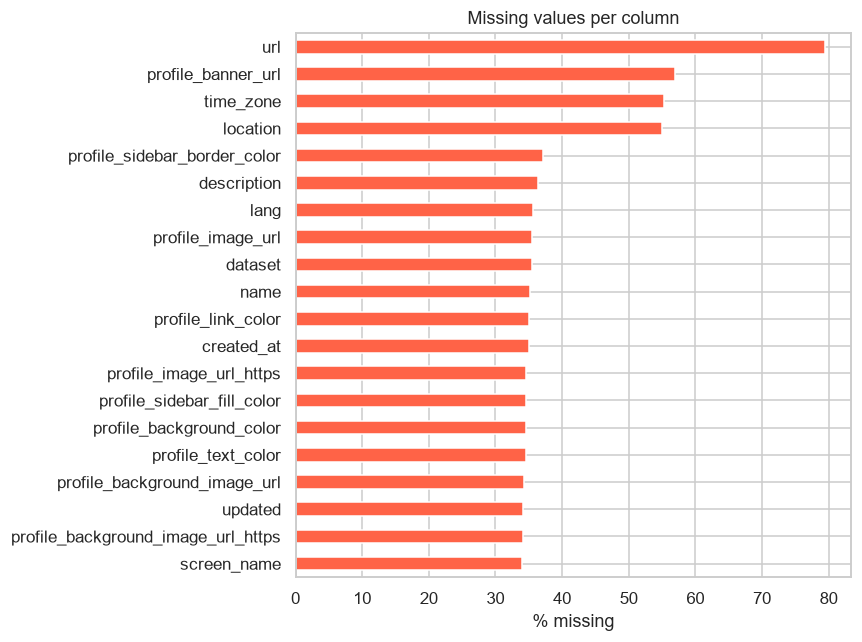

In [4]:
if missing_tbl.empty:
    print("No missing values in this dataset.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_tbl))))
    missing_tbl["missing_pct"].sort_values().plot.barh(ax=ax, color="tomato")
    ax.set_xlabel("% missing")
    ax.set_title("Missing values per column")
    plt.tight_layout()
    plt.show()


## 3. Duplicates

In [5]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
if "id" in df.columns:
    print(f"Duplicated 'id' values: {df['id'].duplicated().sum()}")
    print("Most frequent ids:")
    display(df["id"].value_counts().head(10))


Fully duplicated rows: 0
Duplicated 'id' values: 1252
Most frequent ids:


id
0.000000e+00    1253
1.820663e+09       1
3.263751e+08       1
5.671719e+08       1
2.221044e+09       1
7.213907e+07       1
3.746491e+08       1
1.518565e+08       1
5.323646e+08       1
8.100894e+08       1
Name: count, dtype: int64

## 4. Numeric feature analysis

Note: numeric columns include fields that should be counts or booleans
(`followers_count`, `default_profile`, ...). Their continuous / fractional values
indicate the data has been obfuscated or noise-added.

In [6]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns ({len(num_cols)}):")
display(df[num_cols].describe().T.round(3))


Numeric columns (14):


,count,mean,std,min,25%,50%,75%,max
id,2500.0,3.265032e+08,6.183814e+08,0.0,0.0,0.00,4.120407e+08,5.545508e+09
statuses_count,2500.0,2.592901e+03,8.959140e+03,0.0,0.0,0.00,1.093184e+03,1.396743e+05
followers_count,2500.0,6.306720e+02,1.604859e+04,0.0,0.0,0.00,1.329450e+02,7.960964e+05
friends_count,2500.0,3.297410e+02,8.063920e+02,0.0,0.0,3.63,3.213700e+02,1.687847e+04
favourites_count,2500.0,3.578190e+02,2.480597e+03,0.0,0.0,0.00,2.950100e+01,6.089217e+04
listed_count,2500.0,4.247000e+00,3.273500e+01,0.0,0.0,0.00,1.370000e-01,9.156270e+02
default_profile,2500.0,2.020000e-01,6.500000e-01,0.0,0.0,0.00,0.000000e+00,5.864000e+00
default_profile_image,2500.0,1.000000e-03,3.300000e-02,0.0,0.0,0.00,0.000000e+00,1.621000e+00
geo_enabled,2500.0,3.580000e-01,8.350000e-01,0.0,0.0,0.00,0.000000e+00,6.450000e+00
profile_use_background_image,2500.0,7.470000e-01,1.119000e+00,0.0,0.0,-0.00,1.328000e+00,6.125000e+00


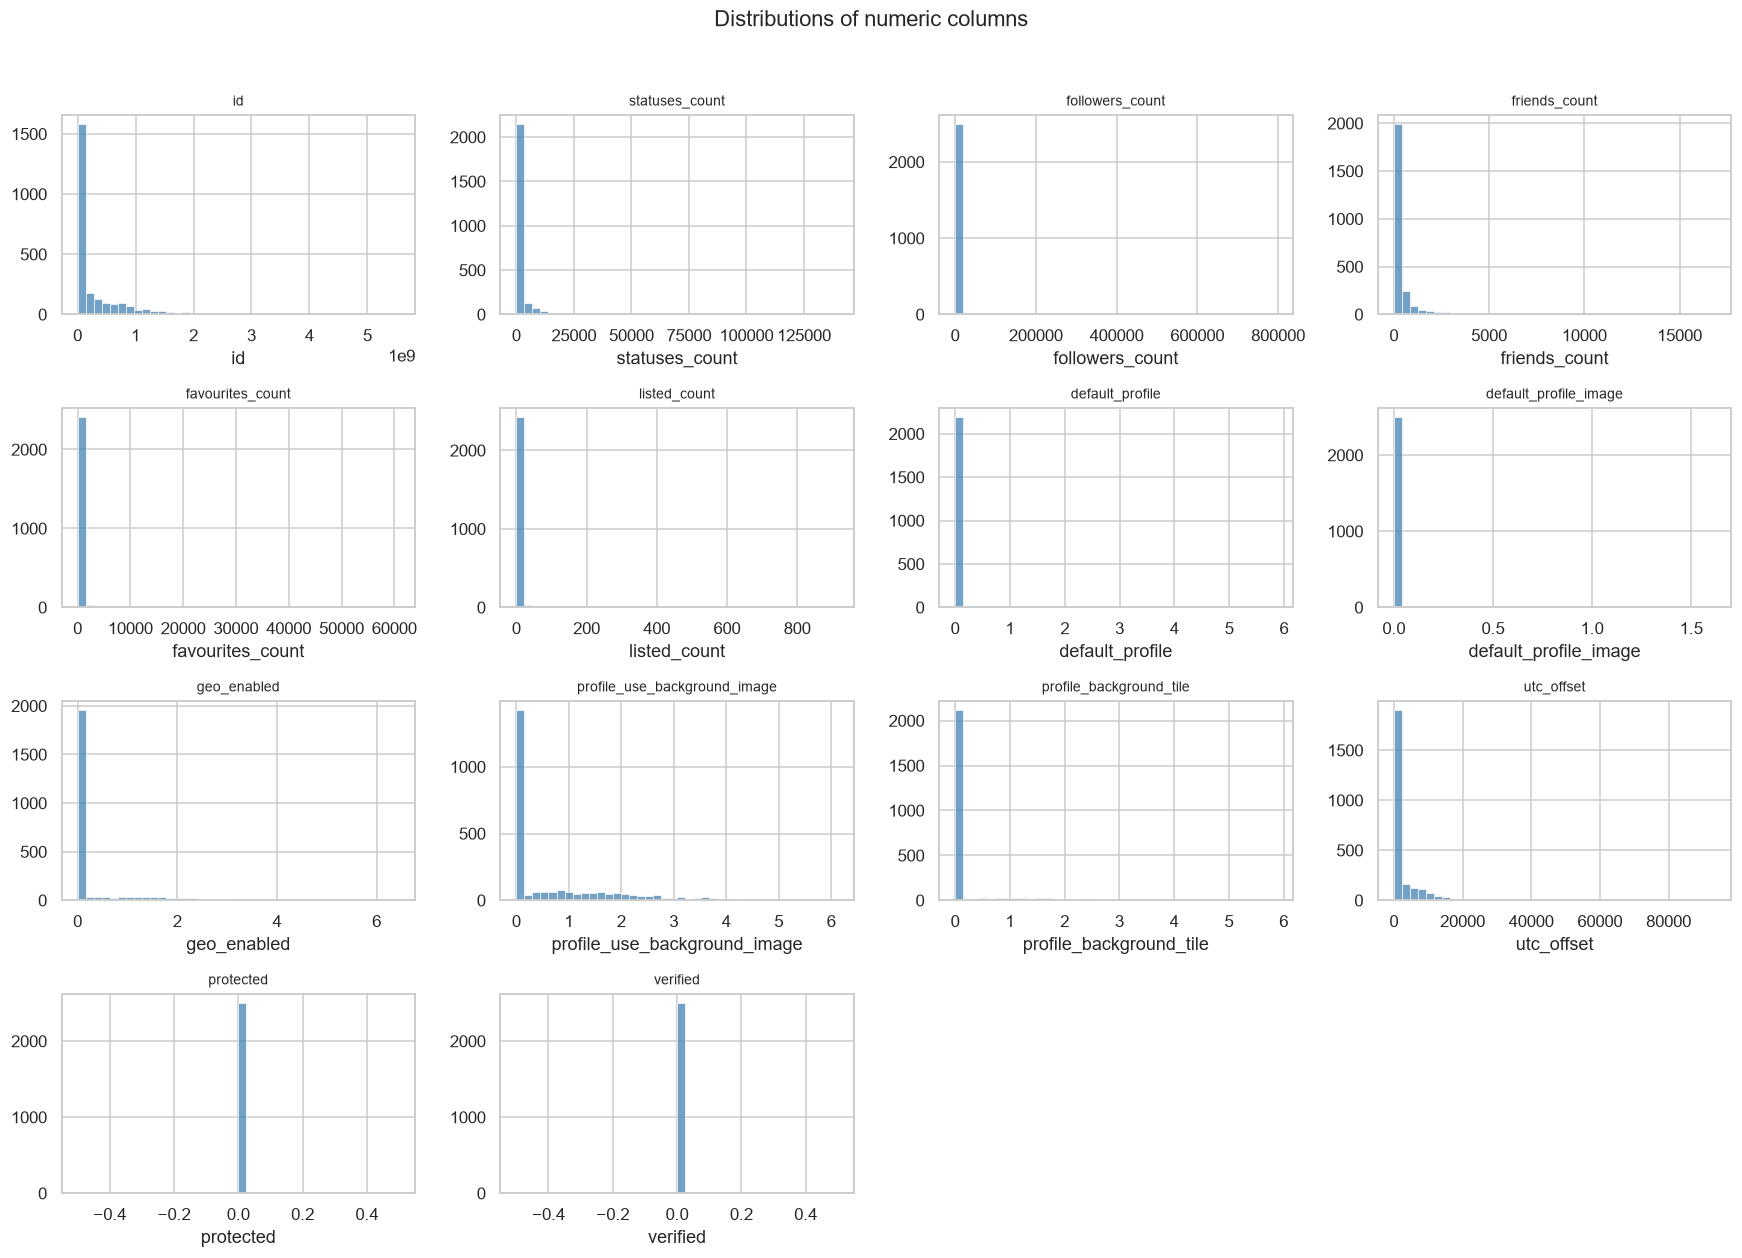

In [7]:
n = len(num_cols)
ncols = min(n, 4)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Distributions of numeric columns", y=1.02)
plt.tight_layout()
plt.show()


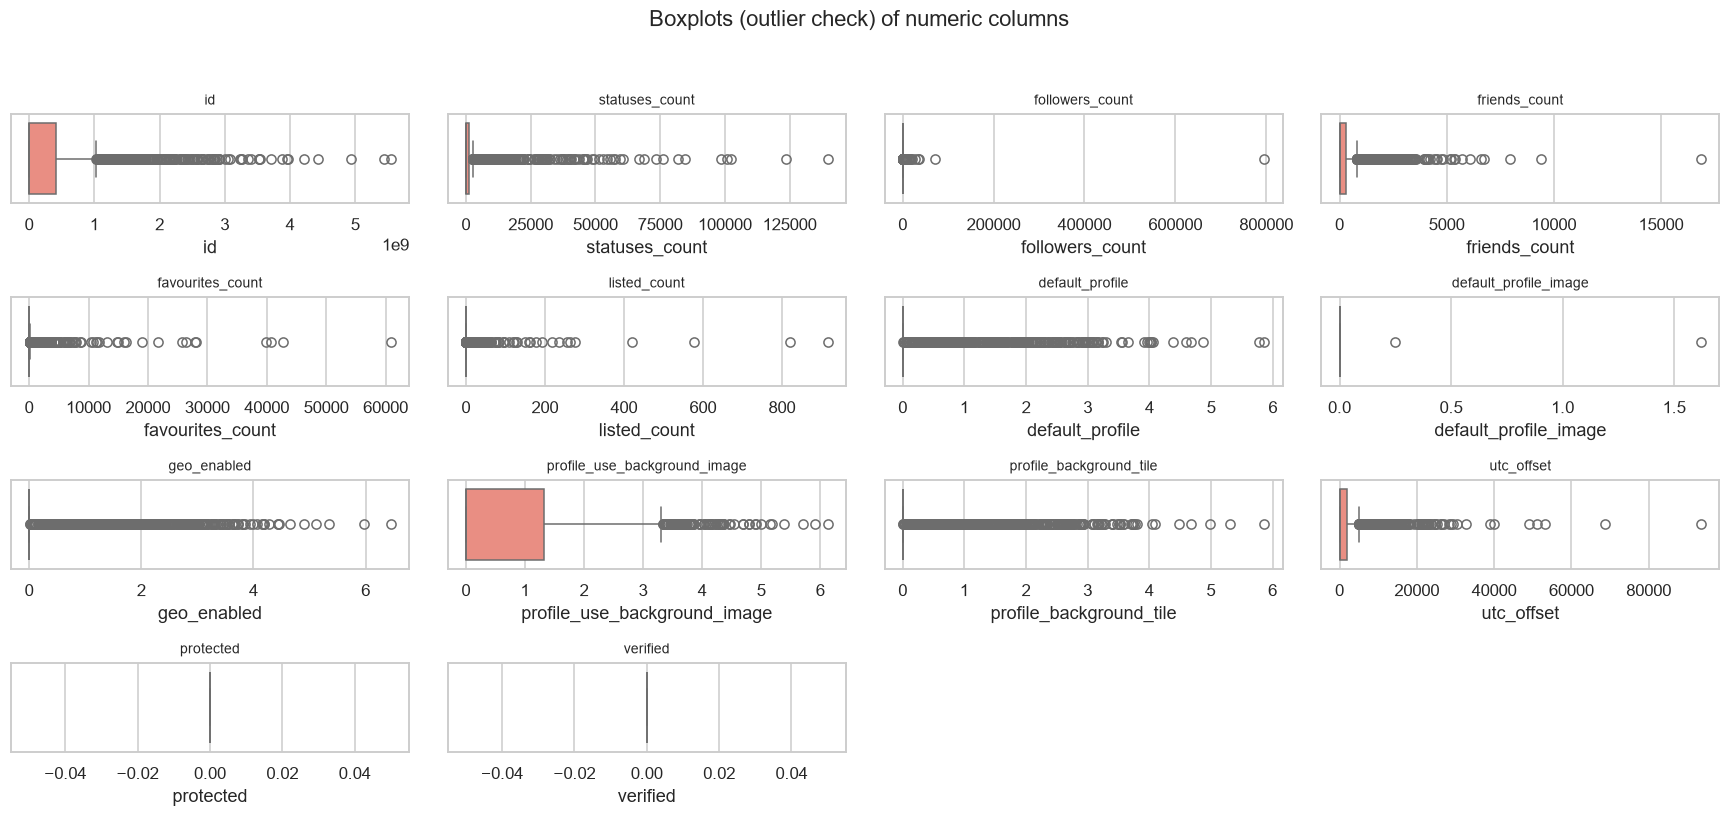

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 1.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="salmon")
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Boxplots (outlier check) of numeric columns", y=1.03)
plt.tight_layout()
plt.show()


## 5. Categorical / text features

In [9]:
cat_cols = [c for c in df.columns if c not in num_cols]
print(f"Non-numeric columns ({len(cat_cols)}):")
overview = pd.DataFrame({
    "nunique": [df[c].nunique(dropna=True) for c in cat_cols],
    "missing_pct": [round(df[c].isna().mean() * 100, 1) for c in cat_cols],
    "example": [str(df[c].dropna().iloc[0])[:60] if df[c].notna().any() else "-" for c in cat_cols],
}, index=cat_cols)
display(overview)


Non-numeric columns (20):


,nunique,missing_pct,example
name,996,35.2,Mamma con i tacchi
screen_name,992,34.0,GLPini
created_at,977,35.0,Mon Nov 07 11:00:27 +0000 2011
url,318,79.4,http://t.co/WRvheMrL
lang,6,35.6,it
time_zone,25,55.3,Rome
location,457,55.0,www.peregoalbum.it
profile_image_url,970,35.5,http://a0.twimg.com/profile_images/2667435229/...
profile_banner_url,664,57.0,https://si0.twimg.com/profile_banners/93446688...
profile_background_image_url_https,521,34.2,https://si0.twimg.com/images/themes/theme11/bg...


Low-cardinality categorical columns: ['lang', 'time_zone']


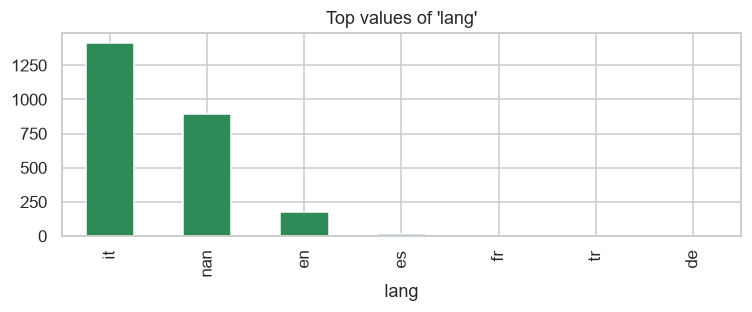

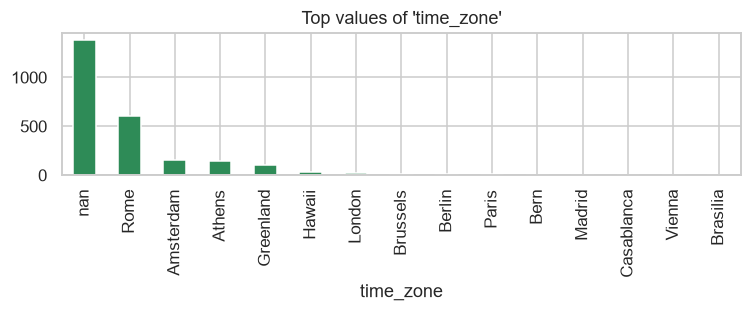

In [10]:
# Top values for the most informative low-cardinality categorical columns
low_card = [c for c in cat_cols if 1 < df[c].nunique(dropna=True) <= 30]
print("Low-cardinality categorical columns:", low_card)
for c in low_card[:8]:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[c].value_counts(dropna=False).head(15).plot.bar(ax=ax, color="seagreen")
    ax.set_title(f"Top values of '{c}'")
    plt.tight_layout()
    plt.show()


## 5b. Account creation dates

`created_at` is parsed to see when accounts were created — bursty creation
periods are a classic fake-account signal.

Parseable created_at values: 1625 / 2500
Year range: 2007.0 - 2013.0


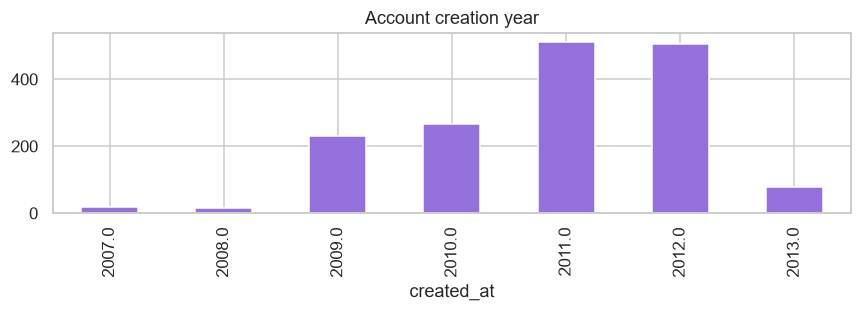

In [11]:
created = pd.to_datetime(df["created_at"], format="%a %b %d %H:%M:%S %z %Y", errors="coerce")
print(f"Parseable created_at values: {created.notna().sum()} / {len(df)}")
print(f"Year range: {created.dt.year.min()} - {created.dt.year.max()}")
fig, ax = plt.subplots(figsize=(8, 3))
created.dt.year.value_counts().sort_index().plot.bar(ax=ax, color="mediumpurple")
ax.set_title("Account creation year")
plt.tight_layout()
plt.show()

## 6. Correlations

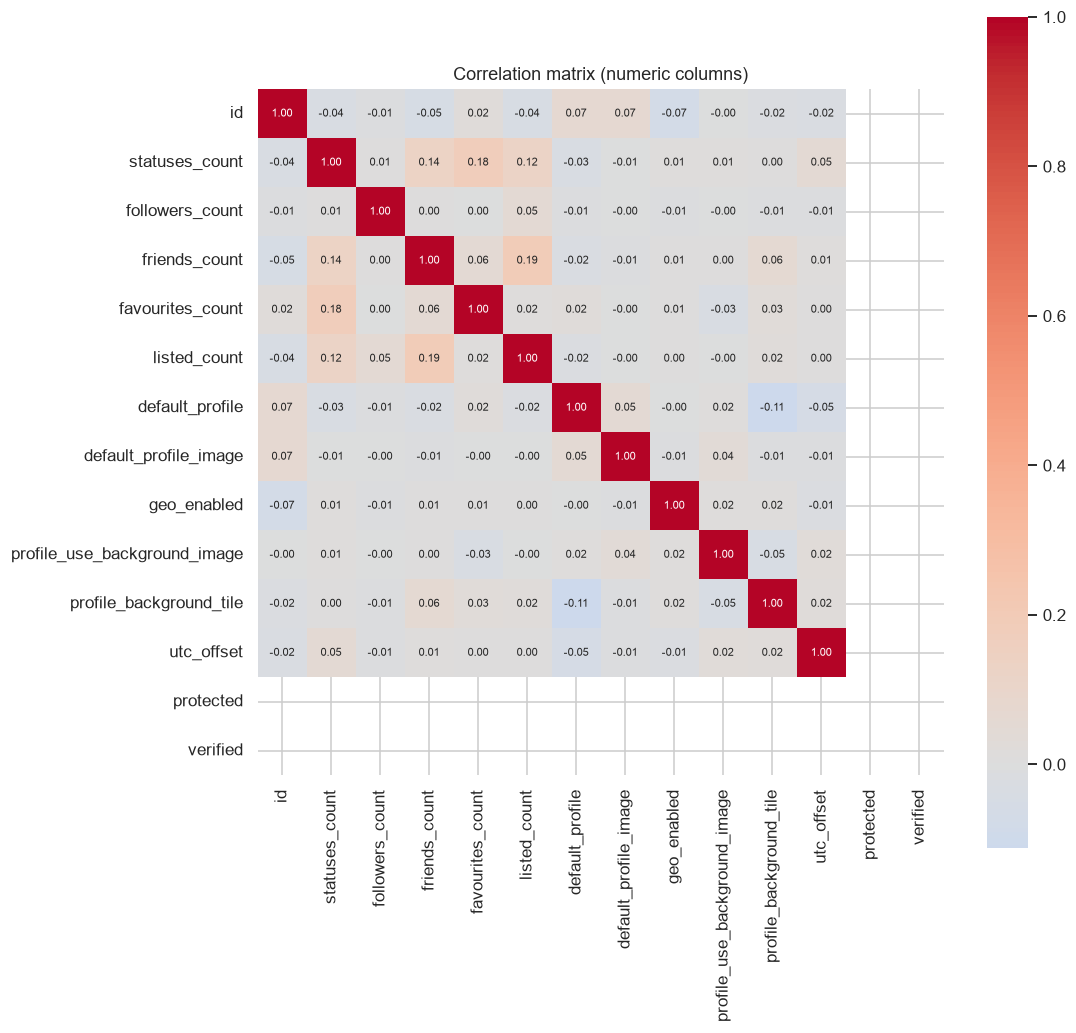

In [12]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(min(14, 0.6 * len(num_cols) + 2), min(12, 0.55 * len(num_cols) + 2)))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=len(num_cols) <= 18,
            fmt=".2f", annot_kws={"size": 7}, square=True)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()


## 7. Comparison with the opposite class

This file only contains **genuine/real** accounts, so we load the complementary
file to compare class-level statistics — this tells us which features are likely
to be discriminative for the model.

In [13]:
other_file = "fake_users.csv" if "real" in DATA_PATH else "real_users.csv"
df_other = pd.read_csv("../data/" + other_file)
print(f"Compared against: {other_file}  ({df_other.shape[0]} rows)")
# keep only columns that are numeric in BOTH files (column dtypes can differ between files)
shared_num = [c for c in num_cols if pd.api.types.is_numeric_dtype(df_other[c])]
means_this = df[shared_num].mean(numeric_only=True)
means_other = df_other[shared_num].mean(numeric_only=True)
comparison = pd.DataFrame({
    "this": means_this,
    "other": means_other,
    "ratio": means_this / means_other.replace(0, np.nan),
}).round(3).sort_values("ratio")
display(comparison)

Compared against: fake_users.csv  (2500 rows)


,this,other,ratio
default_profile_image,1.000000e-03,3.000000e-03,0.240
default_profile,2.020000e-01,7.840000e-01,0.258
id,3.265032e+08,5.489711e+08,0.595
profile_use_background_image,7.470000e-01,8.230000e-01,0.909
friends_count,3.297410e+02,3.009750e+02,1.096
favourites_count,3.578190e+02,8.407000e+00,42.563
followers_count,6.306720e+02,1.315900e+01,47.927
utc_offset,2.240324e+03,3.481200e+01,64.356
statuses_count,2.592901e+03,3.469700e+01,74.730
profile_background_tile,2.540000e-01,3.000000e-03,90.275


## 8. Key observations
- **2,500 rows x 34 columns** of Twitter-profile metadata (counts, profile settings, colors, urls, text fields).
- **Heavy missingness** (~35%) across almost all text fields (`name`, `screen_name`, `lang`, `description`, `time_zone`, `url`, profile color fields...). Missingness itself may be a signal.
- **No fully duplicated rows**, but ~50% of `id` values repeat (many ids are `0.0` after obfuscation) — `id` is not a reliable key.
- **Numeric values look obfuscated/noised**: boolean-like fields (`default_profile`, `geo_enabled`, `profile_background_tile`, `profile_use_background_image`) contain fractional values (e.g. 2.87, 5.86) instead of 0/1; some values are negative (`-0.0`). `protected` and `verified` are all 0.
- Typical "genuine" profile shape: mean followers ~630, mean statuses ~2,593, mean favourites ~358, `listed_count` > 0 frequently.
- Creation dates span 2006–2013 with no single burst year.
- **Modeling implications:** use count features + missingness indicators; avoid `id`; treat boolean-ish columns as noisy numerics; most raw text/url fields are unusable directly, only their missingness/presence helps.